<span style = " color: blue; font-size : 20px; font-weight: bold;"> OVERVIEW - TỔNG QUAN DỰ ÁN <span>

<span style="color:green; font-size:18px; font-weight:bold;">Bối cảnh</span>

Đa dạng hóa danh mục đầu tư là một trong những nguyên tắc quan trọng trong quản lý tài chính nhằm giảm thiểu rủi ro mà vẫn duy trì khả năng sinh lợi. Tuy nhiên, mức độ hiệu quả của đa dạng hóa phụ thuộc đáng kể vào mối tương quan giữa các tài sản trong danh mục. Bên cạnh đó, việc lựa chọn tỷ trọng đầu tư hợp lý cũng đóng vai trò quan trọng trong việc tối ưu hóa mối quan hệ giữa lợi nhuận và rủi ro.

<span style="color:green; font-size:18px; font-weight:bold;">Mục tiêu dự án</span>

Mục tiêu chính của dự án là phân tích hiệu quả của đa dạng hóa danh mục đầu tư và ứng dụng mô hình Markowitz để xây dựng danh mục tối ưu trên thị trường chứng khoán Việt Nam. Các mục tiêu cụ thể bao gồm:

* Phân tích tương quan giữa các cổ phiếu:
  Xác định mức độ tương quan giữa các cổ phiếu thuộc nhiều nhóm ngành khác nhau và nhận diện các cặp cổ phiếu có tương quan cao nhất và thấp nhất.

* Đánh giá tác động của tương quan đến hiệu quả đa dạng hóa:
  So sánh hiệu quả đầu tư giữa danh mục gồm các cổ phiếu có tương quan cao và danh mục gồm các cổ phiếu có tương quan thấp thông qua các chỉ tiêu lợi nhuận, rủi ro và Sharpe Ratio.

* Phân tích ảnh hưởng của số lượng cổ phiếu đến rủi ro danh mục:
  Thực hiện mô phỏng các danh mục có quy mô từ 1 đến 18 cổ phiếu nhằm đánh giá lợi ích của đa dạng hóa trong việc giảm thiểu rủi ro.

* Tối ưu hóa danh mục đầu tư:
  Ứng dụng mô hình Markowitz (Mean-Variance Optimization) để xác định danh mục có Sharpe Ratio lớn nhất và danh mục có phương sai nhỏ nhất.

* Kiểm định hiệu quả đầu tư:
  Thực hiện backtest trên dữ liệu năm 2026 để đánh giá khả năng hoạt động của các chiến lược đầu tư trong điều kiện thị trường thực tế.

<span style="color:green; font-size:18px; font-weight:bold;">Các biến số chính</span>

<span style = "font-weight: bold">Biến đầu vào: <span>

* `Ticker`: Mã cổ phiếu.
* `Date`: Ngày giao dịch.
* `Close Price`: Giá đóng cửa của cổ phiếu.

<span style ="font-weight: bold">Biến được tính toán: <span>

* `Daily Return`: Suất sinh lợi ngày của cổ phiếu.
* `Correlation`: Hệ số tương quan giữa các cổ phiếu.
* `Covariance`: Hiệp phương sai giữa các suất sinh lợi.
* `Portfolio Return`: Lợi nhuận kỳ vọng của danh mục.
* `Portfolio Risk`: Rủi ro (độ biến động) của danh mục.
* `Sharpe Ratio`: Chỉ tiêu đánh giá lợi nhuận điều chỉnh theo rủi ro.
* `Portfolio Weights`: Tỷ trọng đầu tư của từng cổ phiếu trong danh mục.

<span style="color:green; font-size:18px; font-weight:bold;">Nguồn dữ liệu</span>

Dữ liệu được thu thập từ CafeF, bao gồm thông tin giá giao dịch lịch sử của các cổ phiếu niêm yết trên Sở Giao dịch Chứng khoán Thành phố Hồ Chí Minh (HOSE). Nghiên cứu sử dụng dữ liệu của 18 cổ phiếu thuộc 9 nhóm ngành khác nhau trong giai đoạn từ 01/01/2021 đến 01/06/2026. Dữ liệu này được sử dụng để phân tích mối tương quan giữa các cổ phiếu, đánh giá hiệu quả đa dạng hóa và xây dựng các danh mục đầu tư tối ưu.


<span style = " color: blue; font-size : 20px; font-weight: bold;">IMPORT LIBRARIES - NHẬP CÁC THƯ VIỆN CẦN THIẾT <span>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<span style = " color: blue; font-size : 20px; font-weight: bold;"> DATA PREPARATION - CHUẨN BỊ VÀ XỬ LÝ DỮ LIỆU <span>

In [3]:
df=pd.read_csv("CafeF.HSX.Upto01.06.2026.csv")
df['<DTYYYYMMDD>'] = pd.to_datetime(df['<DTYYYYMMDD>'], format='%Y%m%d')
ticker = [
    "VCB","TCB",      
    "SSI","HCM",      
    "VHM","NLG",      
    "FPT","CMG",      
    "MWG","PNJ",     
    "HPG","HSG",      
    "REE","POW",      
    "VNM","MSN",      
    "GMD","VSC"       
]
df = df[df['<DTYYYYMMDD>']>='2021-01-01']
df = df[df['<DTYYYYMMDD>']<='2026-06-01']
stock_data=df[df['<Ticker>'].isin(ticker)].copy()
stock_data.set_index ('<DTYYYYMMDD>', inplace=True)
stock_data.sort_index(inplace=True) 

<span style = " color: blue; font-size : 20px; font-weight: bold;"> STOCK RETURN AND CORRELATION MATRIX - LỢI SUẤT VÀ MA TRẬN TƯƠNG QUAN<span>


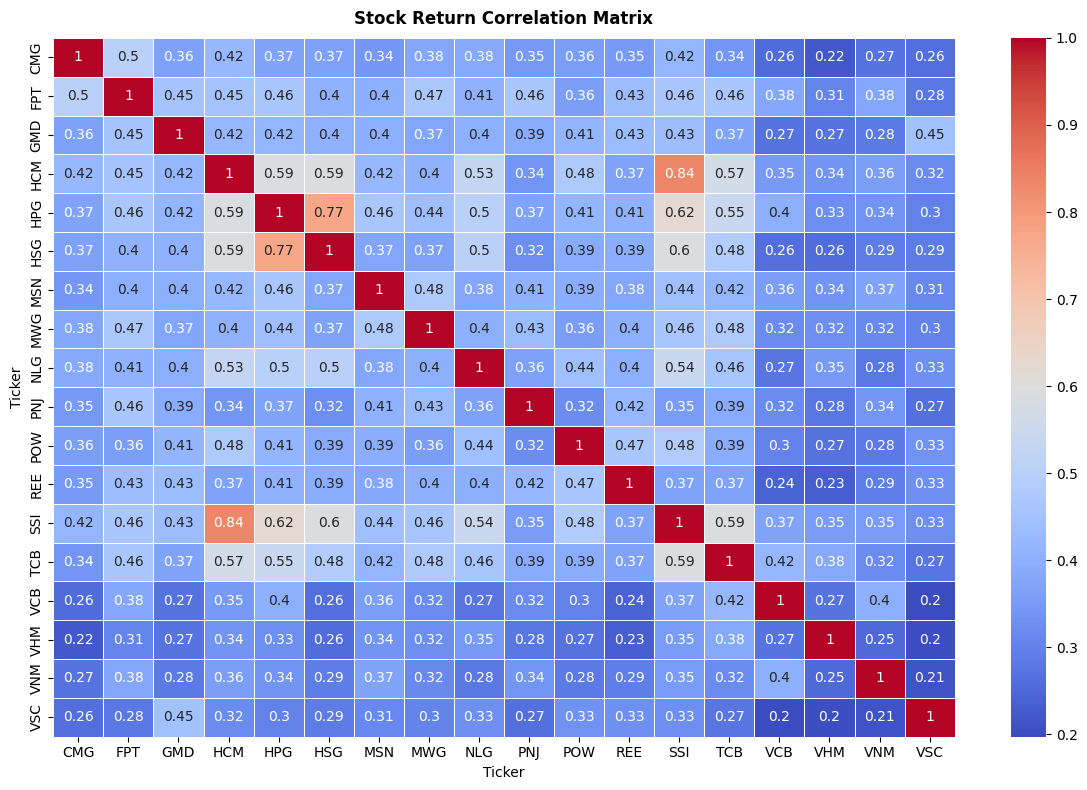

In [4]:
stock_data = stock_data.sort_values([ '<Ticker>',stock_data.index.name])
close_by_ticker = stock_data.groupby('<Ticker>')['<Close>']
stock_data['return'] = close_by_ticker.pct_change()
returns = stock_data.pivot_table(
    index=stock_data.index,
    columns="<Ticker>",
    values="return"
)
returns = returns.dropna()

corr_matrix = returns.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot = True, cmap='coolwarm',linewidths=0.5)
plt.title("Stock Return Correlation Matrix", pad=10, fontweight = 'bold')
plt.xlabel("Ticker")
plt.ylabel("Ticker")
plt.tight_layout()
plt.show()

<span style = " color: blue; font-size : 20px; font-weight: bold;">PORTFOLIO PERFORMANCE COMPARISON BY CORRELATION LEVEL - SO SÁNH HIỆU QUẢ DANH MỤC THEO MỨC ĐỘ TƯƠNG QUAN<span>



Top 10 Highest Correlated Stock Pairs:
        Pair  Correlation
66   HCM-SSI     0.836808
77   HPG-HSG     0.772698
84   HPG-SSI     0.622637
102  HSG-SSI     0.595176
59   HCM-HSG     0.590747
229  SSI-TCB     0.590349
58   HCM-HPG     0.586544
67   HCM-TCB     0.565482
85   HPG-TCB     0.545181
156  NLG-SSI     0.543107

Top 10 Lowest Correlated Stock Pairs:
        Pair  Correlation
269  VCB-VSC     0.197284
287  VHM-VSC     0.201170
305  VNM-VSC     0.212542
15   CMG-VHM     0.220624
213  REE-VHM     0.228847
212  REE-VCB     0.240810
286  VHM-VNM     0.251665
14   CMG-VCB     0.255976
105  HSG-VHM     0.258698
17   CMG-VSC     0.260694

           Metric  High Correlation Portfolio  Low Correlation Portfolio
Annualized Return                    0.182369                   0.196385
  Annualized Risk                    0.358250                   0.235750
     Sharpe Ratio                    0.425316                   0.705771


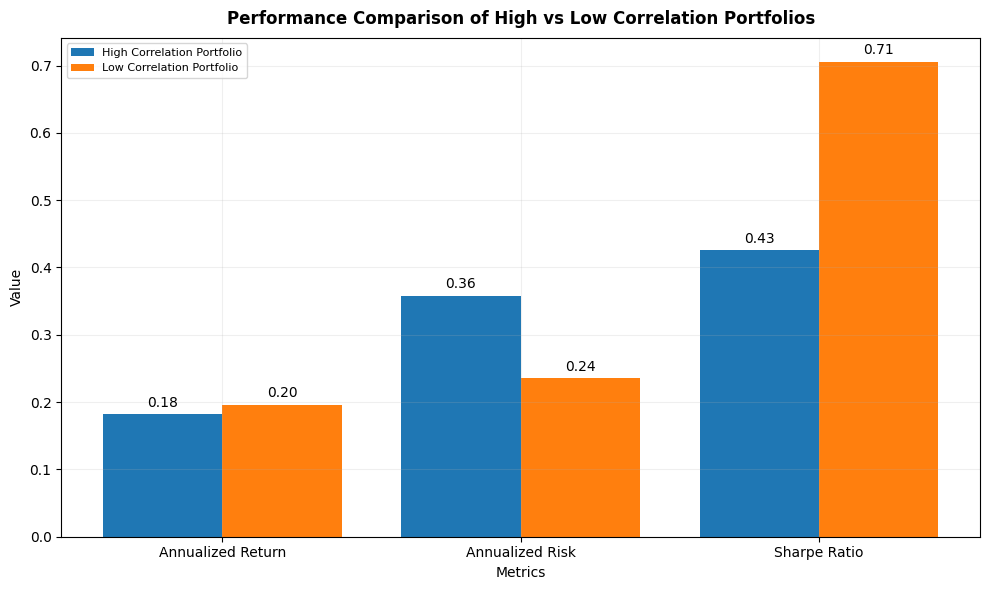

In [13]:
corr_matrix.index.name = "Ticker_1"
corr_matrix.columns.name = "Ticker_2"
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ["Ticker_1", "Ticker_2", "Correlation"]

corr_pairs = corr_pairs[corr_pairs["Ticker_1"] != corr_pairs["Ticker_2"]]

corr_pairs["Pair"] = corr_pairs.apply(
    lambda row: "-".join(sorted([row["Ticker_1"], row["Ticker_2"]])),
    axis=1)
corr_pairs = corr_pairs.drop_duplicates(subset="Pair")

highest_corr = corr_pairs.sort_values(
    by="Correlation",
    ascending=False
).head(10)
print("\nTop 10 Highest Correlated Stock Pairs:")
print(highest_corr[["Pair", "Correlation"]])

lowest_corr = corr_pairs.sort_values(
    by="Correlation",
    ascending=True
).head(10)
print("\nTop 10 Lowest Correlated Stock Pairs:")
print(lowest_corr[["Pair", "Correlation"]])

high_corr_portfolio = ["HCM", "SSI", "HPG", "HSG"]
low_corr_portfolio = ["VCB", "FPT", "MWG", "GMD"]

risk_free_rate = 0.03  

high_corr_portfolio_daily_return = returns[high_corr_portfolio].mean(axis=1)
low_corr_portfolio_daily_return = returns[low_corr_portfolio].mean(axis=1)

high_corr_portfolio_return = high_corr_portfolio_daily_return.mean() * 252
low_corr_portfolio_return = low_corr_portfolio_daily_return.mean() * 252

high_portfolio_risk = high_corr_portfolio_daily_return.std()*252**0.5
low_portfolio_risk = low_corr_portfolio_daily_return.std()*252**0.5


high_portfolio_sharpe = (high_corr_portfolio_return - risk_free_rate) / high_portfolio_risk
low_portfolio_sharpe = (low_corr_portfolio_return - risk_free_rate) / low_portfolio_risk

metrics = ["Annualized Return", "Annualized Risk", "Sharpe Ratio"]
high_value = [high_corr_portfolio_return, high_portfolio_risk, high_portfolio_sharpe]
low_value = [low_corr_portfolio_return, low_portfolio_risk, low_portfolio_sharpe]
comparison_df = pd.DataFrame({
    "Metric": metrics,
    "High Correlation Portfolio": high_value,
    "Low Correlation Portfolio": low_value})
comparison_df = comparison_df.to_string(index=False)
print("\n" + comparison_df)

x = np.arange(len(metrics))
plt.figure(figsize=(10, 6))
bar_1 = plt.bar(x -0.2, high_value, width=0.4, label="High Correlation Portfolio")
bar_2 = plt.bar(x +0.2, low_value, width=0.4, label="Low Correlation Portfolio")
plt.bar_label(bar_1, padding=3, fmt="%.2f", size = 10)
plt.bar_label(bar_2, padding=3, fmt="%.2f", size = 10)
plt.title("Performance Comparison of High vs Low Correlation Portfolios", pad=10, fontweight = 'bold')
plt.xticks(x, metrics)
plt.xlabel("Metrics")
plt.ylabel("Value")
plt.legend(fontsize=8)
plt.grid(alpha = 0.2)
plt.tight_layout()
plt.show()

<span style = " color: BLUE; font-size : 20px; font-weight: bold;">IMPACT OF PORTFOLIO DIVERSIFICATION ON RISK - ẢNH HƯỞNG ĐA DẠNG HÓA DANH MỤC ĐẾN RỦI RO <span>

    Number of Stocks  Average Risk  Min Risk  Max Risk
0                  1      0.356330  0.240260  0.448095
1                  2      0.301262  0.207447  0.415485
2                  3      0.276085  0.199926  0.375249
3                  4      0.264927  0.200970  0.339963
4                  5      0.257914  0.203674  0.335365
5                  6      0.251559  0.198885  0.304424
6                  7      0.248507  0.205459  0.302812
7                  8      0.245427  0.206203  0.297035
8                  9      0.242359  0.205070  0.283854
9                 10      0.240881  0.209326  0.276964
10                11      0.239863  0.212029  0.274315
11                12      0.238430  0.211704  0.267450
12                13      0.236935  0.212175  0.261121
13                14      0.236277  0.216542  0.257105
14                15      0.235452  0.217610  0.252341
15                16      0.234893  0.222507  0.247553
16                17      0.234244  0.227733  0.240371
17        

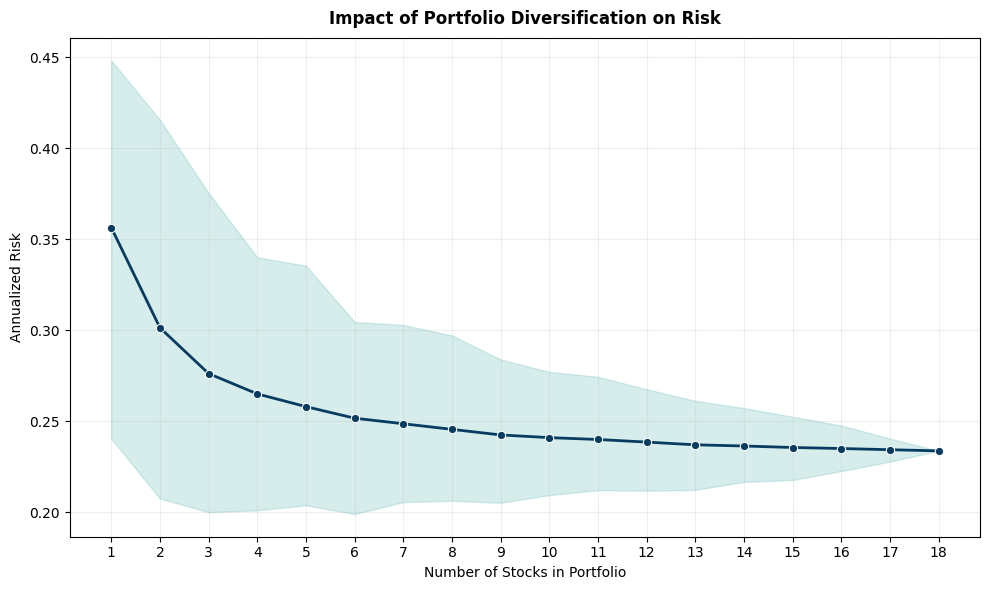

In [7]:
stocks = stock_data["<Ticker>"].unique()
num_simulations = 1000
portfolio_risk_results = []
np.random.seed(2026)

for num_stock in range (1, (len(stocks)+1)):
    risk = []
    for i in range(0, num_simulations):
        selected_stocks = np.random.choice(stocks, size=num_stock, replace=False)
        portfolio_daily_return = returns[selected_stocks].mean(axis=1)
        portfolio_annual_risk = portfolio_daily_return.std()*(252**0.5)
        risk.append(portfolio_annual_risk)
    avg_risk = np.mean(risk)
    min_risk = np.min(risk)
    max_risk = np.max(risk)
    portfolio_risk_results.append({
        "Number of Stocks": num_stock,
        "Average Risk": avg_risk,
        "Min Risk": min_risk,
        "Max Risk": max_risk
    })
risk_by_num_stocks_df = pd.DataFrame(portfolio_risk_results)
print(risk_by_num_stocks_df)

plt.figure(figsize=(10, 6))
sns.lineplot(data = risk_by_num_stocks_df, x = 'Number of Stocks', y = 'Average Risk', linewidth = 2, marker ='o',color = "#083b60")
plt.fill_between(risk_by_num_stocks_df ['Number of Stocks'], 
                 risk_by_num_stocks_df['Min Risk'], 
                 risk_by_num_stocks_df['Max Risk'], color="#39a8a2", alpha=0.2)
plt.xticks(risk_by_num_stocks_df['Number of Stocks'])
plt.xlabel("Number of Stocks in Portfolio")
plt.ylabel("Annualized Risk")
plt.title("Impact of Portfolio Diversification on Risk", pad=10, fontweight = 'bold')
plt.grid(alpha = 0.2)
plt.tight_layout()
plt.show()


Expected Annualized Returns 

Ticker
CMG    0.163274
FPT    0.244264
GMD    0.277654
HCM    0.264274
HPG    0.141046
HSG    0.099282
MSN    0.077939
MWG    0.150494
NLG    0.130922
PNJ    0.165972
POW    0.110134
REE    0.198037
SSI    0.224876
TCB    0.198006
VCB    0.113129
VHM    0.231279
VNM   -0.026133
VSC    0.174545
dtype: float64


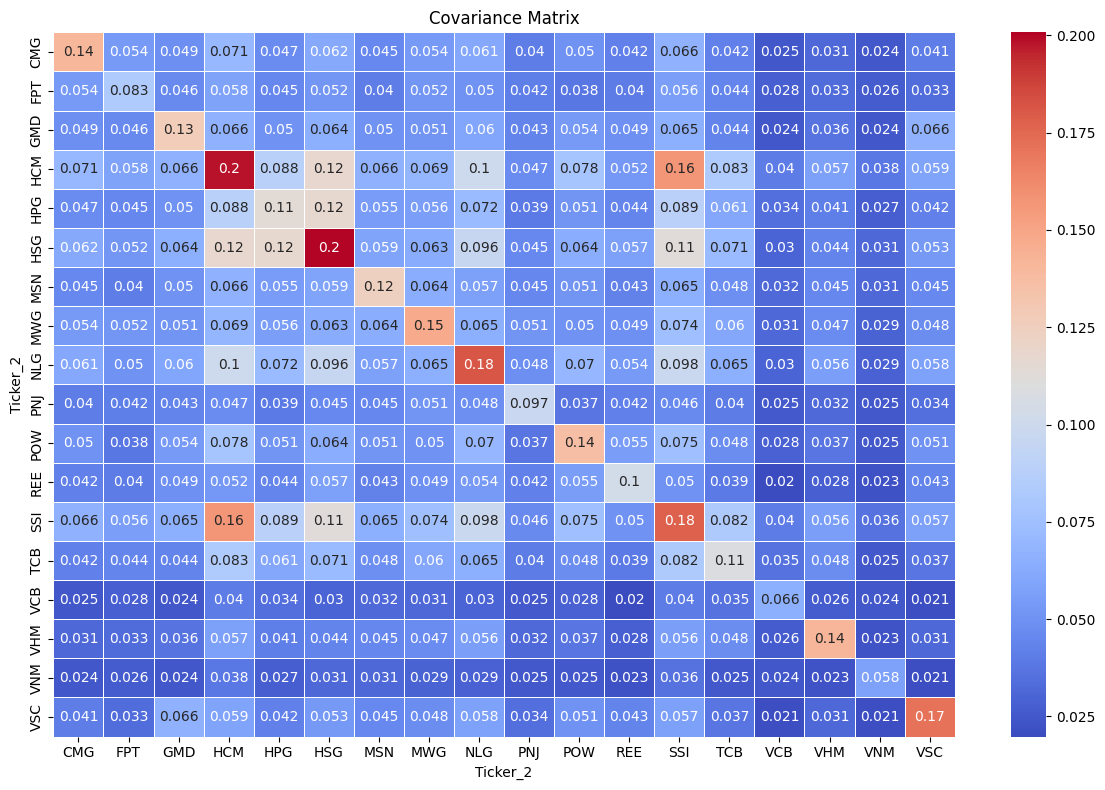


Max Sharpe Portfolio Weights:
   Ticker    Weight
1     FPT  0.157349
15    VHM  0.156781
2     GMD  0.141767
17    VSC  0.123817
3     HCM  0.093078
12    SSI  0.058907
10    POW  0.049813
0     CMG  0.038227
6     MSN  0.034614
4     HPG  0.027052
9     PNJ  0.026592
5     HSG  0.025606
7     MWG  0.022636
14    VCB  0.020017
13    TCB  0.010077
8     NLG  0.007198
11    REE  0.005974
16    VNM  0.000495

Minimum Variance Portfolio Weights:
   Ticker    Weight
14    VCB  0.114141
9     PNJ  0.103058
11    REE  0.100709
1     FPT  0.093317
16    VNM  0.092736
2     GMD  0.085730
6     MSN  0.055476
17    VSC  0.054807
15    VHM  0.054102
0     CMG  0.049283
5     HSG  0.043722
4     HPG  0.033729
13    TCB  0.030084
7     MWG  0.027265
10    POW  0.024467
12    SSI  0.020858
8     NLG  0.016243
3     HCM  0.000273


In [17]:
expected_returns = returns.mean() * 252
expected_returns.index.name = "Ticker"
print("\nExpected Annualized Returns \n" )
print(expected_returns)
covariance_matrix = returns.cov() * 252

plt.figure(figsize = (12, 8))
sns.heatmap (covariance_matrix, annot = True, cmap='coolwarm', linewidths=0.5)
plt.title("Covariance Matrix")
plt.tight_layout()
plt.show()

num_portfolios = 10000
risk_free_rate = 0.03
stocks = stock_data["<Ticker>"].unique()
np.random.seed(2026)
portfolio_results = []
for i in range (0, num_portfolios):
    weight = np.random.random(len(stocks))
    weight = weight / np.sum(weight)
    portfolio_return = np.dot(weight, expected_returns)
    portfolio_risk = np.sqrt(np.dot(weight.T, np.dot(covariance_matrix, weight)))
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_risk if portfolio_risk != 0 else 0
    portfolio_results.append({
        "Return": portfolio_return,
        "Risk": portfolio_risk,
        "Sharpe Ratio": sharpe_ratio,
        "Weights": weight
    })
markowitz_results = pd.DataFrame(portfolio_results)

max_sharpe_portfolio = markowitz_results.loc[markowitz_results['Sharpe Ratio'].idxmax()]
min_variance_portfolio = markowitz_results.loc[markowitz_results['Risk'].idxmin()]
max_sharpe_weights = pd.DataFrame({
    "Ticker": stocks,
    "Weight": max_sharpe_portfolio["Weights"]
}).sort_values("Weight", ascending=False)

min_variance_weights = pd.DataFrame({
    "Ticker": stocks,
    "Weight": min_variance_portfolio["Weights"]
}).sort_values("Weight", ascending=False)

print("\nMax Sharpe Portfolio Weights:")
print(max_sharpe_weights)

print("\nMinimum Variance Portfolio Weights:")
print(min_variance_weights)


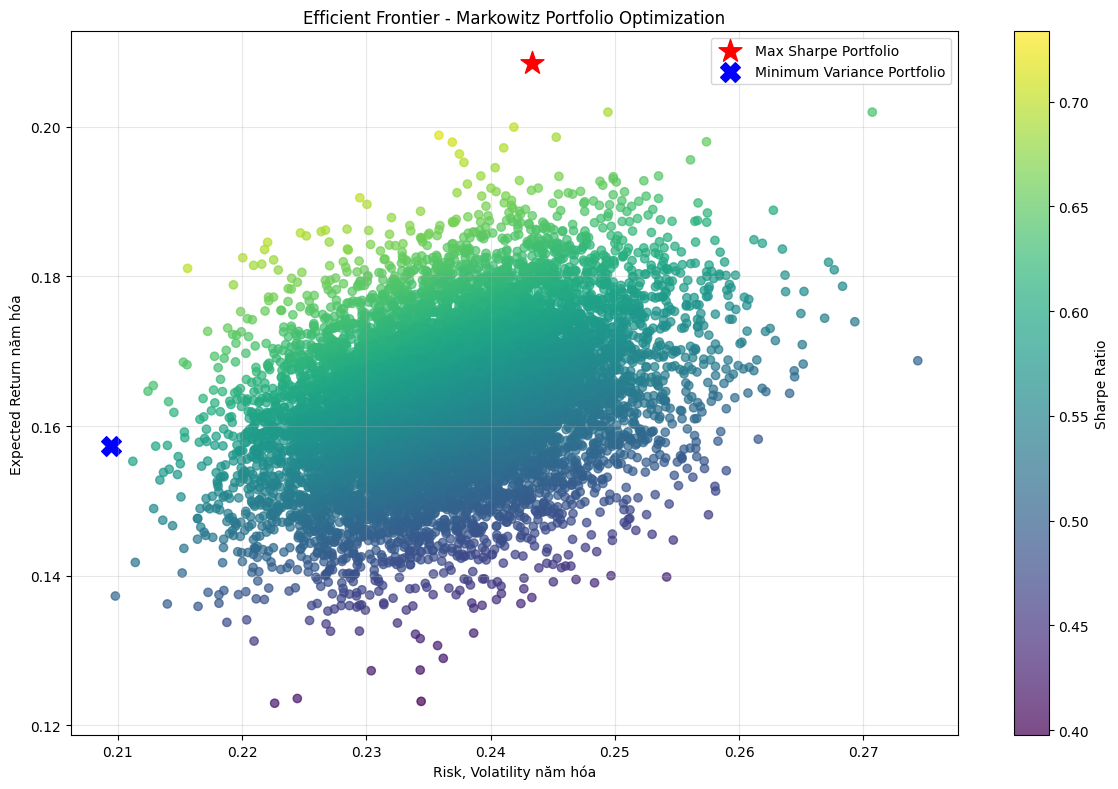

In [ ]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    markowitz_results["Risk"],
    markowitz_results["Return"],
    c=markowitz_results["Sharpe Ratio"],
    cmap="viridis",
    alpha=0.7
)
plt.colorbar(scatter, label="Sharpe Ratio")
plt.scatter(
    max_sharpe_portfolio["Risk"],
    max_sharpe_portfolio["Return"],
    color="red",
    marker="*",
    s=300,
    label="Max Sharpe Portfolio"
)
plt.scatter(
    min_variance_portfolio["Risk"],
    min_variance_portfolio["Return"],
    color="blue",
    marker="X",
    s=200,
    label="Minimum Variance Portfolio"
)
plt.title("Efficient Frontier - Markowitz Portfolio Optimization")
plt.xlabel("Risk, Volatility năm hóa")
plt.ylabel("Expected Return năm hóa")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Backtest Performance (2026):
      Portfolio  Annual Return  Annual Risk  Sharpe Ratio
0    Max Sharpe       0.011175     0.234175     -0.080389
1  Min Variance       0.039938     0.227348      0.043713
2  Equal Weight       0.041745     0.231976      0.050631


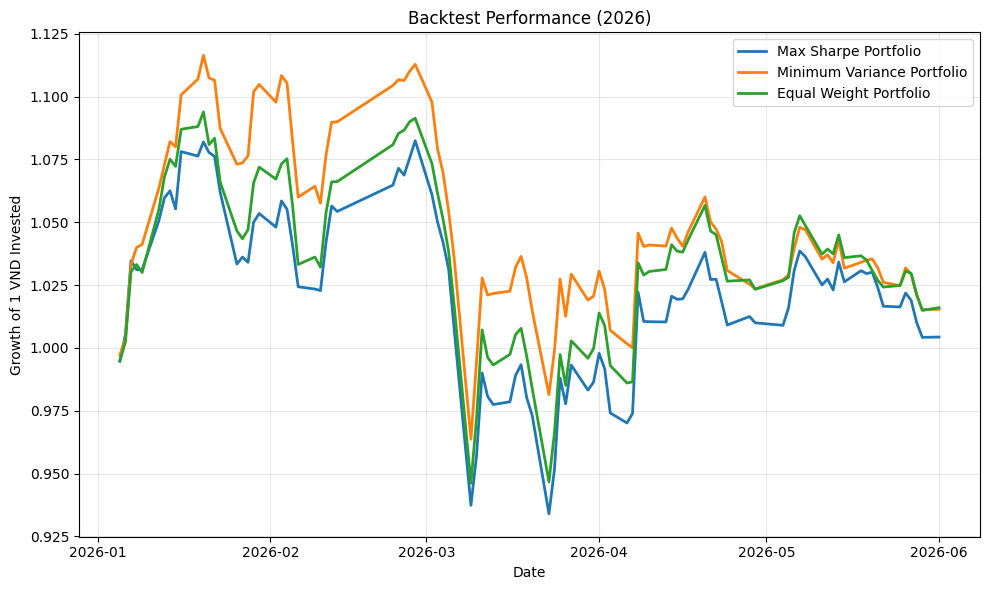


Max Sharpe Portfolio Weights:
   Ticker    Weight
11    REE  0.131615
1     FPT  0.127768
12    SSI  0.119793
2     GMD  0.116782
15    VHM  0.093046
0     CMG  0.079291
7     MWG  0.059124
13    TCB  0.044776
14    VCB  0.038066
4     HPG  0.035877
17    VSC  0.034895
10    POW  0.034094
3     HCM  0.029101
6     MSN  0.020238
16    VNM  0.018101
5     HSG  0.011717
8     NLG  0.003216
9     PNJ  0.002501

Minimum Variance Portfolio Weights:
   Ticker    Weight
14    VCB  0.114141
9     PNJ  0.103058
11    REE  0.100709
1     FPT  0.093317
16    VNM  0.092736
2     GMD  0.085730
6     MSN  0.055476
17    VSC  0.054807
15    VHM  0.054102
0     CMG  0.049283
5     HSG  0.043722
4     HPG  0.033729
13    TCB  0.030084
7     MWG  0.027265
10    POW  0.024467
12    SSI  0.020858
8     NLG  0.016243
3     HCM  0.000273


In [18]:
train_returns = returns[returns.index < "2026-01-01"]
test_returns = returns[returns.index >= "2026-01-01"]

expected_returns_bt = train_returns.mean() * 252
covariance_matrix_bt = train_returns.cov() * 252

risk_free_rate = 0.03
num_portfolios = 10000
stocks = expected_returns_bt.index

np.random.seed(2026)
portfolio_results_bt = []
for i in range(num_portfolios):
    weights = np.random.random(len(stocks))
    weights = weights / weights.sum()
    portfolio_return = np.dot(weights, expected_returns_bt)
    portfolio_risk = np.sqrt(
        np.dot(weights.T,
               np.dot(covariance_matrix_bt, weights))
    )
    sharpe_ratio = (
        (portfolio_return - risk_free_rate)
        / portfolio_risk
    )
    portfolio_results_bt.append({
        "Return": portfolio_return,
        "Risk": portfolio_risk,
        "Sharpe": sharpe_ratio,
        "Weights": weights
    })
portfolio_results_bt = pd.DataFrame(portfolio_results_bt)


max_sharpe_weights_bt = portfolio_results_bt.loc[ portfolio_results_bt["Sharpe"].idxmax(),"Weights"]
min_variance_weights_bt = portfolio_results_bt.loc[portfolio_results_bt["Risk"].idxmin(),"Weights"]

max_sharpe_return = (
    test_returns[stocks]
    * max_sharpe_weights_bt
).sum(axis=1)

min_variance_return = (
    test_returns[stocks]
    * min_variance_weights_bt
).sum(axis=1)

equal_weights = np.repeat(
    1 / len(stocks),
    len(stocks)
)

equal_return = (
    test_returns[stocks]
    * equal_weights
).sum(axis=1)

backtest_result = pd.DataFrame({
    "Max Sharpe": max_sharpe_return,
    "Min Variance": min_variance_return,
    "Equal Weight": equal_return
})

performance = []
for col in backtest_result.columns:
    annual_return = (
        (1 + backtest_result[col]).prod()
    ) ** (252 / len(backtest_result)) - 1
    annual_risk = (
        backtest_result[col].std()
        * np.sqrt(252)
    )
    sharpe = (
        (annual_return - risk_free_rate)
        / annual_risk
    )
    performance.append({
        "Portfolio": col,
        "Annual Return": annual_return,
        "Annual Risk": annual_risk,
        "Sharpe Ratio": sharpe
    })
performance = pd.DataFrame(performance)
print("\nBacktest Performance (2026):")
print(performance)

cumulative_return = (
    1 + backtest_result
).cumprod()

plt.figure(figsize=(10, 6))
plt.plot(
    cumulative_return.index,
    cumulative_return["Max Sharpe"],
    label="Max Sharpe Portfolio",
    linewidth=2
)
plt.plot(
    cumulative_return.index,
    cumulative_return["Min Variance"],
    label="Minimum Variance Portfolio",
    linewidth=2
)
plt.plot(
    cumulative_return.index,
    cumulative_return["Equal Weight"],
    label="Equal Weight Portfolio",
    linewidth=2
)
plt.title(
    "Backtest Performance (2026)"
)
plt.xlabel("Date")
plt.ylabel("Growth of 1 VND Invested")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nMax Sharpe Portfolio Weights:")
print(
    pd.DataFrame({
        "Ticker": stocks,
        "Weight": max_sharpe_weights_bt
    }).sort_values("Weight", ascending=False)
)
print("\nMinimum Variance Portfolio Weights:")
print(
    pd.DataFrame({
        "Ticker": stocks,
        "Weight": min_variance_weights_bt
    }).sort_values("Weight", ascending=False)
)